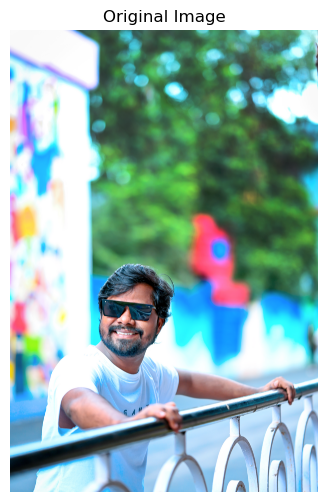

Select the object to use as template.
Click and drag around the object, then press ENTER.
Template Width : 355
Template Height: 212
Similarity Score: 1.0
Best Match Location: (329, 543)


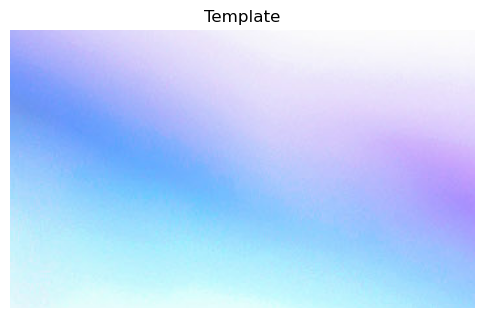

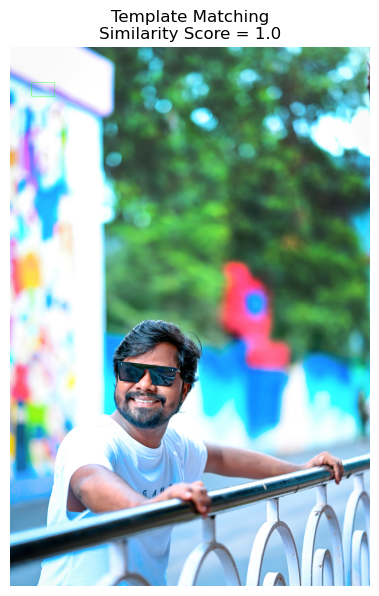

In [1]:
import cv2
import matplotlib.pyplot as plt

# ============================================================
# TEMPLATE MATCHING PRACTICAL
# ============================================================

# 1. Read the main image
image = cv2.imread("02.jpg")

if image is None:
    print("Error: book.jpg not found.")
else:

    # --------------------------------------------------------
    # 2. Display the image
    # --------------------------------------------------------
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

    # --------------------------------------------------------
    # 3. Select the object/template manually
    # --------------------------------------------------------
    print("Select the object to use as template.")
    print("Click and drag around the object, then press ENTER.")

    x, y, w, h = cv2.selectROI(
        "Select Template",
        image,
        fromCenter=False,
        showCrosshair=True
    )

    cv2.destroyAllWindows()

    # Check whether a region was selected
    if w == 0 or h == 0:
        print("No template selected.")
    else:

        # ----------------------------------------------------
        # 4. Crop the selected region
        # ----------------------------------------------------
        template = image[y:y+h, x:x+w]

        # ----------------------------------------------------
        # 5. Convert both images to grayscale
        # ----------------------------------------------------
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        gray_template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

        # ----------------------------------------------------
        # 6. Get template size
        # ----------------------------------------------------
        th, tw = gray_template.shape

        print("Template Width :", tw)
        print("Template Height:", th)

        # ----------------------------------------------------
        # 7. Perform Template Matching
        # ----------------------------------------------------
        result = cv2.matchTemplate(
            gray_image,
            gray_template,
            cv2.TM_CCOEFF_NORMED
        )

        # ----------------------------------------------------
        # 8. Find the best matching location
        # ----------------------------------------------------
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

        print("Similarity Score:", round(max_val, 4))
        print("Best Match Location:", max_loc)

        # ----------------------------------------------------
        # 9. Draw rectangle around detected object
        # ----------------------------------------------------
        top_left = max_loc
        bottom_right = (
            top_left[0] + tw,
            top_left[1] + th
        )

        output = image.copy()

        cv2.rectangle(
            output,
            top_left,
            bottom_right,
            (0, 255, 0),
            3
        )

        # ----------------------------------------------------
        # 10. Display Template
        # ----------------------------------------------------
        plt.figure(figsize=(6, 4))
        plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
        plt.title("Template")
        plt.axis("off")
        plt.show()

        # ----------------------------------------------------
        # 11. Display Matching Result
        # ----------------------------------------------------
        plt.figure(figsize=(10, 7))
        plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        plt.title(
            "Template Matching\n"
            + "Similarity Score = "
            + str(round(max_val, 4))
        )
        plt.axis("off")
        plt.show()